### Importing relevant libraries

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Loading dataset

In [54]:
df = pd.read_csv('Iris.csv')

### Getting basic dataset overview

In [47]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [48]:
df.shape

(150, 6)

In [49]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

### Basic descriptive statistics

Iris-setosa        50
Iris-virginica     50
Iris-versicolor    50
Name: Species, dtype: int64

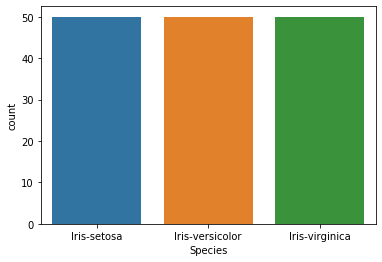

In [50]:
#Checking the unique species and their count

sns.countplot(x = 'Species', data = df)

df['Species'].value_counts()

### Evaluating data quality/health

In [51]:
#Checking for missing values

df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [52]:
#Checking for duplicated records

df.duplicated.sum()

AttributeError: 'function' object has no attribute 'sum'

In [55]:
'''This shows the total identical records as opposed to the above code showing just the sum of the extra copies, i.e it shows the originals too.'''


df.duplicated(keep = False).sum()

0

In [57]:
#Displays the actual identical rows, not just their sum

dups = df[df.duplicated(keep = False)]
print(dups)

Empty DataFrame
Columns: [Id, SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm, Species]
Index: []


In [58]:
#Dropping all duplicates (keeping originals i.e first instances)

df.drop_duplicates(keep ='first', inplace = True)

In [59]:
#Checking to make sure there are no more duplicates

df.duplicated().sum()

0

In [60]:
#Dropping the id column as it is irrelevant to both analysis and modeling

df.drop('Id', axis = 1, inplace = True)

### Data Visualisation and Analysis

In [61]:
#Variables that would be useful for subplotting

features = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
target = df['Species']

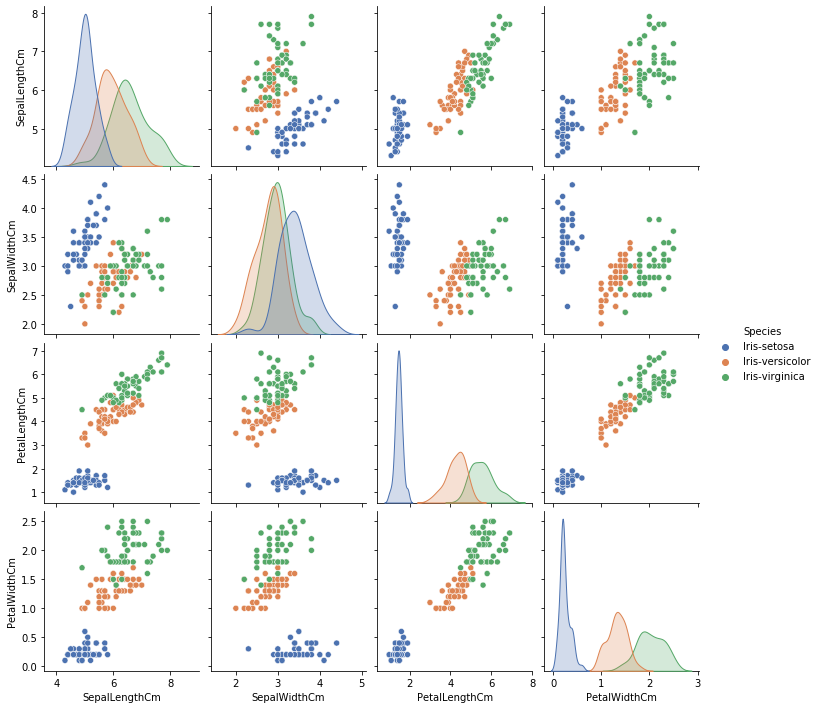

In [62]:
#Checking correlation of all features to eaach other by species

sns.pairplot(df, hue = 'Species', palette = 'deep')
plt.show()

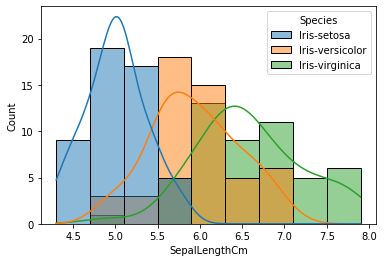

In [63]:
sns.histplot(data = df, x = df['SepalLengthCm'], hue = 'Species', kde = True)
plt.show()

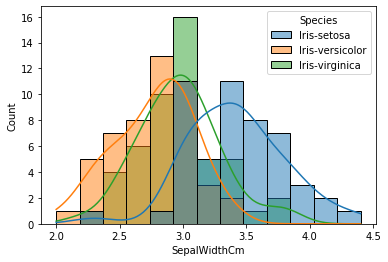

In [64]:
sns.histplot(data = df, x = df['SepalWidthCm'], hue = 'Species', kde = True)
plt.show()

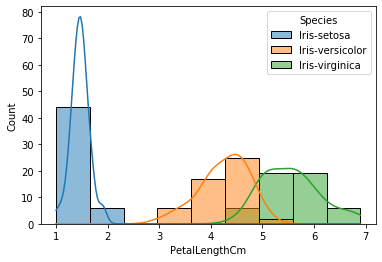

In [65]:
sns.histplot(data = df, x = df['PetalLengthCm'], hue = 'Species', kde = True)
plt.show()

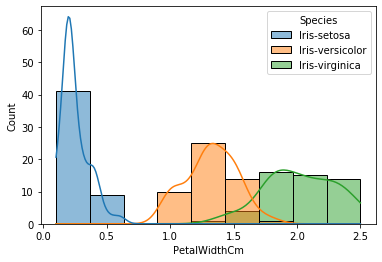

In [66]:
sns.histplot(data = df, x = df['PetalWidthCm'], hue = 'Species', kde = True)
plt.show()

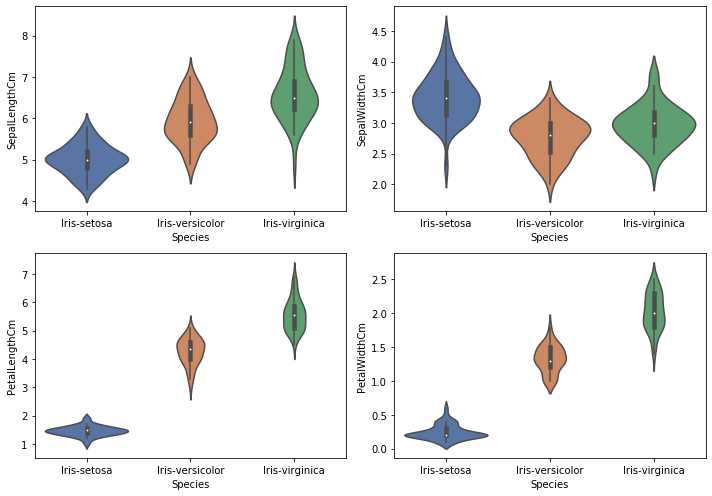

In [69]:
plt.figure(figsize = (10, 7))
for i, feature in enumerate (features):
    plt.subplot (2, 2, i + 1)
    sns.violinplot(x = 'Species', y = feature, palette ='deep', data = df)
    
plt.tight_layout()
plt.show()


<Figure size 1080x720 with 0 Axes>

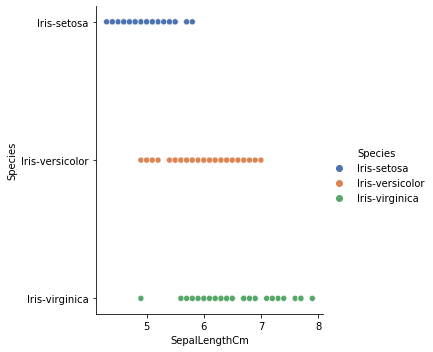

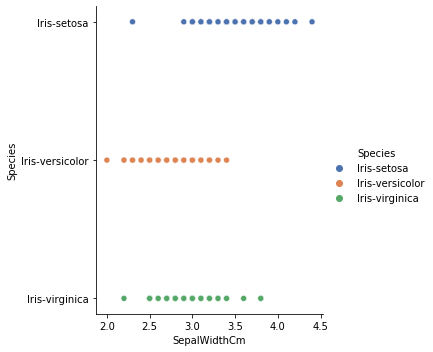

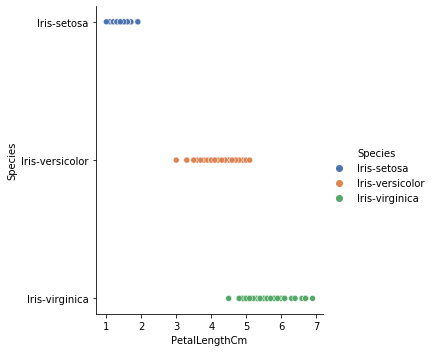

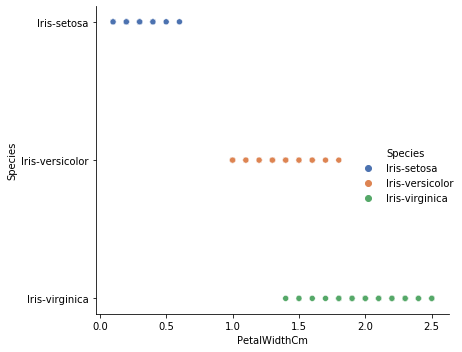

In [68]:
plt.figure(figsize = (15, 10))
for i, feature in enumerate (features):
    sns.relplot(x = feature, y = 'Species', hue = 'Species', palette = 'deep', data = df)
plt.tight_layout()

plt.show()

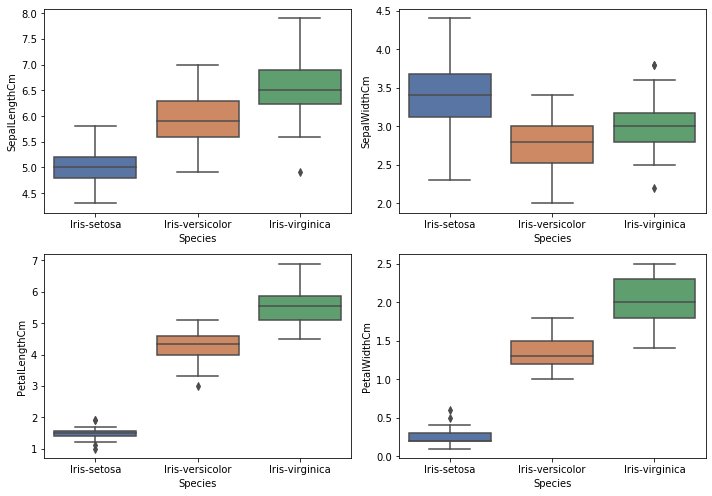

In [72]:
fig, axes = plt.subplots(2, 2, figsize = (10, 7))
axes = axes.flatten()

for i, feature in enumerate (features):
    sns.boxplot (data = df, x = 'Species', y = feature, palette = 'deep', ax = axes[i])
    
plt.tight_layout()
plt.show()

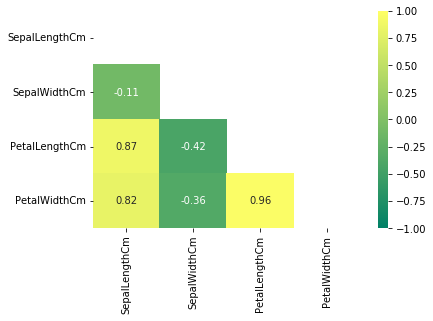

In [47]:
#Masking to remove duplicate correlations
mask = np.ones((4,4), dtype = int)
for i in range(len(mask)):
    for j in range(i):
        mask[i,j] = 0

corr = df.corr()
sns.heatmap(corr, annot = True, fmt = '.2f', cmap = 'summer', vmin = -1, vmax = 1, mask = mask)

C:\Users\User\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 10.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


C:\Users\User\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 22.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


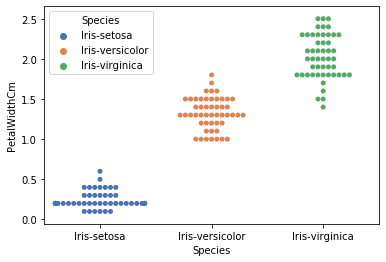

In [76]:
sns.swarmplot(data = df, x = 'Species', hue = 'Species', palette = 'deep', y = 'PetalWidthCm')

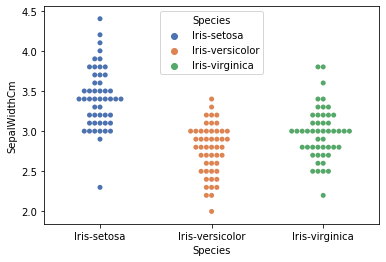

In [84]:
sns.swarmplot(data = df, x = 'Species', hue = 'Species', palette = 'deep', y = 'SepalWidthCm')

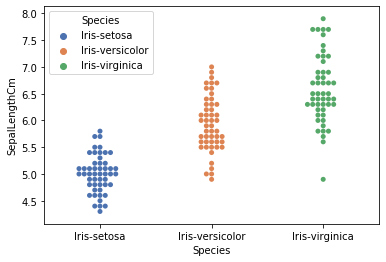

In [85]:
sns.swarmplot(data = df, x = 'Species', hue = 'Species', palette = 'deep', y = 'SepalLengthCm')

C:\Users\User\anaconda3\lib\site-packages\seaborn\categorical.py:3544: UserWarning: 18.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


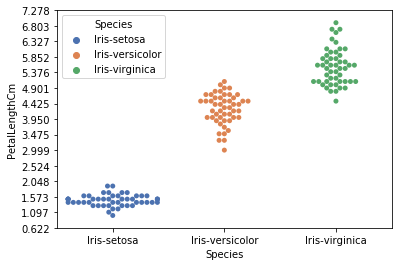

In [94]:
sns.swarmplot(data = df, x = 'Species', hue = 'Species', palette = 'deep', y = 'PetalLengthCm')
y_min, y_max = plt.ylim()
plt.yticks(np.linspace(y_min,y_max,15))
plt.show()

### Observations from the above visualisation

1. Setosa is the smaller of the three species, while virginica is the largest.
2. Setosa appears notably distinguished (especially in petal length and width) from the other two, which overlap more.
3. The clearest correlation among paired features exists between petal length and petal width.

### Encoding Target Variable in Preparation for Learning
Label Encoding is used as one-hot encoding (dummies) works better for features not target variable.

In [98]:
species_map = {'Iris-setosa':0, 'Iris-versicolor':1, 'Iris-virginica':2}

df['Species'] = df['Species'].map(species_map)

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Exporting Cleaned Dataset

In [99]:
df.to_csv('Cleaned Iris.csv', index = False)